# Análisis de Redes Científicas con Grafos

**Área:** Procesamiento de Lenguaje Natural (PLN)

**Asignatura:** Estructuras de Datos — Proyecto Unidad 5

**Equipo:**
+ Couoh Concha Valeria Fernanda
+ Gonzalez Chablé Said Alfredo
+ Maas Tuyub Ricardo Esteban
+ Tenorio Cauich Pedro Tenorio

---

Se construyó una red de colaboración científica en PLN usando datos reales de la API de Semantic Scholar. Cada nodo es un investigador, cada arista es una co-autoría, y el peso indica el número de publicaciones compartidas.

## 0. Importaciones y configuración

Ejecuta la siguiente celda para verificar que todas las librerías estén instaladas. Si alguna falla con un error tipo `ModuleNotFoundError: No module named 'paquete'`, interrumpe la celda y corre `pip install <paquete>` en la terminal con el venv activado (debe aparecer `(venv)` al inicio del prompt). Una vez instalado, vuelve a ejecutar la celda.

In [3]:
import json                          # leer y escribir el JSON de papers descargados
import time                          # pausar entre consultas a la API (rate limit)
from collections import Counter, defaultdict  # contar y agrupar miembros por comunidad
from itertools import combinations   # generar pares de co-autores para crear aristas
from pathlib import Path             # manejar rutas de archivos entre sistemas operativos

import requests                      # hacer peticiones HTTP a la API de Semantic Scholar
import networkx as nx                # construir y analizar el grafo de colaboraciones
import matplotlib.pyplot as plt      # generar las visualizaciones estáticas del grafo
import pandas as pd                  # mostrar datos tabulares en rankings y resultados
import community as community_louvain  # algoritmo Louvain para detección de comunidades

print('NetworkX:', nx.__version__)
print('Pandas:', pd.__version__)
print('Todo listo.')

NetworkX: 3.6.1
Pandas: 3.0.3
Todo listo.


## 1. Recolección de datos (10 pts)

## 1. Recolección de datos (10 pts)

Esta celda descarga papers reales de PLN desde la API de Semantic Scholar y los guarda en un JSON local (`data/papers_pln_raw.json`). Se ejecutan múltiples queries de términos PLN para diversificar los resultados y garantizar más de 100 autores únicos. Si el archivo ya existe en disco, se carga directamente sin volver a consultar la API.

El endpoint es `https://api.semanticscholar.org/graph/v1/paper/search`

> El `User-Agent` está configurado de forma genérica. Si lo deseas, puedes personalizarlo agregando tu institución o correo de contacto para identificar mejor las peticiones ante la API.

In [ ]:
# Configuración 
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
RAW_PAPERS_PATH = DATA_DIR / 'papers_pln_raw.json'

API_BASE_URL = 'https://api.semanticscholar.org/graph/v1/paper/search'
API_FIELDS = 'title,year,authors.authorId,authors.name'

# Identificarnos ante la API ayuda a evitar throttling agresivo
REQUEST_HEADERS = {
    'User-Agent': 'UADY-EstructurasDatos-Proyecto/1.0 (academic)'
}

# Parámetros de configuración para la descarga de papers
PAPERS_PER_QUERY = 100
REQUEST_TIMEOUT_SECONDS = 30
SLEEP_BETWEEN_QUERIES_SECONDS = 8        
RATE_LIMIT_BACKOFF_BASE_SECONDS = 30     
MAX_RETRIES = 5

# Términos PLN
PLN_QUERIES = [
    'natural language processing',
    'computational linguistics',
    'language model',
    'text classification',
    'named entity recognition',
    'machine translation',
    'sentiment analysis',
    'question answering',
]

# Descarga papers para una sola query
def fetch_papers_for_query(query: str, limit: int = PAPERS_PER_QUERY) -> list | None:
    """Descarga papers de Semantic Scholar para una query.

    Retorna la lista de papers, o None si la API falló después de los reintentos.
    """
    params = {'query': query, 'limit': limit, 'fields': API_FIELDS}

    for retry_index in range(MAX_RETRIES):
        response = requests.get(
            API_BASE_URL,
            params=params,
            headers=REQUEST_HEADERS,
            timeout=REQUEST_TIMEOUT_SECONDS,
        )

        if response.status_code == 200:
            return response.json().get('data', [])

        if response.status_code == 429:
            wait_seconds = RATE_LIMIT_BACKOFF_BASE_SECONDS * (retry_index + 1)
            print(f'  Rate limit alcanzado, esperando {wait_seconds}s...')
            time.sleep(wait_seconds)
            continue

        print(f'  Error HTTP {response.status_code} en query "{query}"')
        return None

    print(f'  Reintentos agotados para query "{query}"')
    return None

# Recorre todas las queries y junta los papers sin repetir
def collect_unique_papers(queries: list[str]) -> list[dict]:
    """Recolecta papers únicos (deduplicados por paperId) ejecutando múltiples queries."""
    papers: list[dict] = []
    seen_paper_ids: set[str] = set()

    for query in queries:
        print(f'Consultando: "{query}"')
        result = fetch_papers_for_query(query)

        if result is None:
            print('  Falló, se omite esta query.')
            continue

        new_papers_count = 0
        for paper in result:
            paper_id = paper.get('paperId')
            if paper_id and paper_id not in seen_paper_ids:
                seen_paper_ids.add(paper_id)
                papers.append(paper)
                new_papers_count += 1

        print(f'  {len(result)} obtenidos, {new_papers_count} nuevos.')
        time.sleep(SLEEP_BETWEEN_QUERIES_SECONDS)

    return papers

# Cuenta cuántos autores únicos hay en todos los papers descargados
def count_unique_authors(papers: list[dict]) -> int:
    """Cuenta autores únicos (por authorId) en la lista de papers."""
    author_ids = {
        author['authorId']
        for paper in papers
        for author in (paper.get('authors') or [])
        if author.get('authorId')
    }
    return len(author_ids)


# Ejecución
if RAW_PAPERS_PATH.exists():
    print(f'Ya existe {RAW_PAPERS_PATH}, cargando desde disco.')
    with open(RAW_PAPERS_PATH, encoding='utf-8') as f:
        papers = json.load(f)
else:
    papers = collect_unique_papers(PLN_QUERIES)

    with open(RAW_PAPERS_PATH, 'w', encoding='utf-8') as f:
        json.dump(papers, f, ensure_ascii=False, indent=2)
    print(f'\nGuardado en {RAW_PAPERS_PATH}')

print(f'\nTotal papers: {len(papers)}')
print(f'Autores únicos: {count_unique_authors(papers)}')

Ya existe data/papers_pln_raw.json, cargando desde disco.

Total papers: 200
Autores únicos: 933


## 2. Construcción del grafo (15 pts)

**Modelado:**
- Nodos = autores (atributos: nombre, total de papers, años activos)
- Aristas = co-autorías
- Peso = número de papers compartidos entre el par

**Requisito:** mínimo 100 autores.

In [ ]:
# Cargar papers desde el JSON
with open(RAW_PAPERS_PATH, encoding='utf-8') as f:
    papers = json.load(f)

print(f'Papers cargados: {len(papers)}')


# Construcción del grafo
def build_collaboration_graph(papers: list[dict]) -> nx.Graph:
    """Construye un grafo no dirigido y ponderado de colaboraciones científicas.

    Nodos: autores (key = authorId), con atributos name, paper_count, years.
    Aristas: co-autorías. Peso = número de papers compartidos por el par.
    """
    graph = nx.Graph()

    for paper in papers:
        year = paper.get('year')
        authors_with_id = [
            author for author in (paper.get('authors') or [])
            if author.get('authorId')
        ]

        for author in authors_with_id:
            author_id = author['authorId']
            if graph.has_node(author_id):
                graph.nodes[author_id]['paper_count'] += 1
                if year:
                    graph.nodes[author_id]['years'].add(year)
            else:
                graph.add_node(
                    author_id,
                    name=author.get('name', 'Unknown'),
                    paper_count=1,
                    years={year} if year else set(),
                )

        unique_author_ids = list({author['authorId'] for author in authors_with_id})
        for author_id_a, author_id_b in combinations(unique_author_ids, 2):
            if graph.has_edge(author_id_a, author_id_b):
                graph[author_id_a][author_id_b]['weight'] += 1
            else:
                graph.add_edge(author_id_a, author_id_b, weight=1)

    return graph


# Construimos el grafo completo (todos los autores) y luego lo filtramos.
G_full = build_collaboration_graph(papers)

print('\n=== Grafo completo (referencia) ===')
print(f'Nodos:    {G_full.number_of_nodes()}')
print(f'Aristas:  {G_full.number_of_edges()}')


# Filtrado: top-150 autores por degree dentro de la componente gigante para mejor análisis y visualización
TARGET_NODE_COUNT = 150

# 1) Componente gigante del grafo completo
giant_full_nodes = max(nx.connected_components(G_full), key=len)
giant_full = G_full.subgraph(giant_full_nodes).copy()

# 2) Top-N autores por degree dentro de la componente gigante
top_by_degree = sorted(giant_full.degree(), key=lambda item: item[1], reverse=True)
top_node_ids = [node_id for node_id, _ in top_by_degree[:TARGET_NODE_COUNT]]

# 3) Subgrafo inducido por esos nodos
filtered = giant_full.subgraph(top_node_ids).copy()

# 4) Conservamos solo la componente gigante final (por si quedaron sub-piezas)
final_giant_nodes = max(nx.connected_components(filtered), key=len)
G = filtered.subgraph(final_giant_nodes).copy()


# Estadísticas del grafo filtrado
print(f'\n=== Grafo filtrado (top {TARGET_NODE_COUNT} por degree) ===')
print(f'Nodos:                            {G.number_of_nodes()}')
print(f'Aristas:                          {G.number_of_edges()}')
print(f'Densidad:                         {nx.density(G):.4f}')

degrees = dict(G.degree())
average_degree = sum(degrees.values()) / G.number_of_nodes()
print(f'Grado promedio:                   {average_degree:.2f}')
print(f'Grado máximo:                     {max(degrees.values())}')

edge_weights = [data['weight'] for _, _, data in G.edges(data=True)]
average_weight = sum(edge_weights) / len(edge_weights) if edge_weights else 0
print(f'Peso promedio de aristas:         {average_weight:.2f}')

top_by_papers = sorted(
    G.nodes(data=True),
    key=lambda node: node[1]['paper_count'],
    reverse=True,
)[:5]

print('\nTop 5 autores por número de papers (en el grafo filtrado):')
for author_id, attrs in top_by_papers:
    print(f"  {attrs['name']:40s}  ({attrs['paper_count']} papers)")

Papers cargados: 200

=== Grafo completo (referencia) ===
Nodos:    933
Aristas:  8130

=== Grafo filtrado (top 150 por degree) ===
Nodos:                            150
Aristas:                          3945
Densidad:                         0.3530
Grado promedio:                   52.60
Grado máximo:                     114
Peso promedio de aristas:         1.21

Top 5 autores por número de papers (en el grafo filtrado):
  B. Haddow                                 (10 papers)
  Philipp Koehn                             (8 papers)
  C. Federmann                              (7 papers)
  Roman Grundkiewicz                        (7 papers)
  M. Krikun                                 (6 papers)


## 3. Análisis (20 pts)

### 3a. Caminos mínimos

Encontrar rutas de colaboración entre autores. Usamos Dijkstra con peso invertido (`1 / peso`) para que más co-autorías signifique menor distancia.

In [5]:
# Caminos mínimos
# El peso original es "nº de papers compartidos" (más es mejor).
# Para que Dijkstra interprete "más colaboraciones" como "más cerca",
# agregamos un atributo 'distance' = 1 / weight.

for _, _, edge_data in G.edges(data=True):
    edge_data['distance'] = 1.0 / edge_data['weight']

# G ya es la componente gigante del subgrafo filtrado (definido en la celda anterior).
# Lo alias como 'giant' para que las celdas posteriores sigan funcionando.
giant = G

print(f'Grafo de trabajo: {giant.number_of_nodes()} nodos, '
      f'{giant.number_of_edges()} aristas (componente conexa)')


# Ejemplo: camino más corto entre los dos top autores
top_authors = sorted(
    G.nodes(data=True),
    key=lambda node: node[1]['paper_count'],
    reverse=True,
)
author_source_id, author_source_attrs = top_authors[0]
author_target_id, author_target_attrs = top_authors[1]

if nx.has_path(G, author_source_id, author_target_id):
    path = nx.shortest_path(
        G, author_source_id, author_target_id, weight='distance',
    )
    path_names = [G.nodes[node]['name'] for node in path]

    print(f'\nCamino más corto de {author_source_attrs["name"]} '
          f'a {author_target_attrs["name"]}:')
    print('  ' + '  →  '.join(path_names))
    print(f'  ({len(path) - 1} salto(s))')
else:
    print(f'\n{author_source_attrs["name"]} y {author_target_attrs["name"]} '
          f'no están conectados.')


# Estadísticas globales 
print('\n=== Métricas globales (grafo filtrado, sin pesos) ===')
average_path_length = nx.average_shortest_path_length(giant)
diameter = nx.diameter(giant)
print(f'Longitud promedio de caminos: {average_path_length:.2f}')
print(f'Diámetro (camino más largo entre dos autores): {diameter}')

Grafo de trabajo: 150 nodos, 3945 aristas (componente conexa)

Camino más corto de B. Haddow a Philipp Koehn:
  B. Haddow  →  Philipp Koehn
  (1 salto(s))

=== Métricas globales (grafo filtrado, sin pesos) ===
Longitud promedio de caminos: 1.83
Diámetro (camino más largo entre dos autores): 4


### 3b. Centralidad

Calculamos e interpretamos:
- **Degree centrality:** ¿quién tiene más colaboradores directos?
- **Betweenness centrality:** ¿quién actúa como puente entre subgrupos?
- **Closeness centrality:** ¿quién está más cerca de todos los demás en promedio?

In [6]:
# Centralidad
# Calculamos las tres centralidades sobre la componente gigante.
# Trabajar sobre el grafo completo daría resultados engañosos: los nodos
# aislados tendrían closeness mal definida y betweenness = 0 artificial.

print(f'Calculando centralidad en la componente gigante '
      f'({giant.number_of_nodes()} nodos)...')

degree_centrality = nx.degree_centrality(giant)
betweenness_centrality = nx.betweenness_centrality(giant, weight='distance')
closeness_centrality = nx.closeness_centrality(giant, distance='distance')


def top_n_by_metric(
    metric_values: dict,
    graph: nx.Graph,
    n: int = 10,
) -> list[tuple[str, float]]:
    """Devuelve los top-N autores ordenados por la métrica dada."""
    ranked = sorted(metric_values.items(), key=lambda item: item[1], reverse=True)
    return [(graph.nodes[node_id]['name'], value) for node_id, value in ranked[:n]]


def print_centrality_ranking(title: str, interpretation: str, ranking: list) -> None:
    """Imprime un ranking de centralidad con título e interpretación."""
    print(f'\n=== {title} ===')
    print(f'({interpretation})')
    for name, value in ranking:
        print(f'  {name:40s}  {value:.4f}')


print_centrality_ranking(
    'Top 10 por Degree Centrality',
    'Cuántos colaboradores directos tiene cada autor (normalizado)',
    top_n_by_metric(degree_centrality, giant),
)

print_centrality_ranking(
    'Top 10 por Betweenness Centrality',
    'Qué tan frecuentemente un autor aparece en los caminos más cortos entre otros pares — actúa como "puente" entre subgrupos',
    top_n_by_metric(betweenness_centrality, giant),
)

print_centrality_ranking(
    'Top 10 por Closeness Centrality',
    'Qué tan cerca está un autor del resto de la red en promedio — los "más céntricos" llegan a todos rápido',
    top_n_by_metric(closeness_centrality, giant),
)

Calculando centralidad en la componente gigante (150 nodos)...

=== Top 10 por Degree Centrality ===
(Cuántos colaboradores directos tiene cada autor (normalizado))
  Hady ElSahar                              0.7651
  M. Costa-jussà                            0.6242
  Loïc Barrault                             0.6107
  Cynthia Gao                               0.5302
  Holger Schwenk                            0.5302
  Guillaume Wenzek                          0.5302
  Kaushik Ram Sadagopan                     0.5235
  Skyler Wang                               0.5235
  Jean Maillard                             0.5235
  Safiyyah Saleem                           0.5235

=== Top 10 por Betweenness Centrality ===
(Qué tan frecuentemente un autor aparece en los caminos más cortos entre otros pares — actúa como "puente" entre subgrupos)
  Hady ElSahar                              0.4259
  M. Costa-jussà                            0.1970
  Julia Kreutzer                            0.0735
  Gui

### 3c. Componentes conexas

Analizamos:
- Cuántas componentes hay
- Tamaño de la componente gigante
- Autores aislados (componentes de tamaño 1)
- Qué tan conectada está la red en general

In [7]:
# Componentes conexas
# Para esta sección usamos G_full (el grafo completo sin filtrar) para mostrar
# el panorama real de la red: cuántas componentes existen y cómo se distribuyen.
components = list(nx.connected_components(G_full))
component_sizes = sorted((len(component) for component in components), reverse=True)

isolated_authors = sum(1 for size in component_sizes if size == 1)
small_components = sum(1 for size in component_sizes if 2 <= size <= 5)
medium_components = sum(1 for size in component_sizes if 6 <= size <= 30)
large_components = sum(1 for size in component_sizes if size > 30)

print('=== Componentes conexas (grafo completo) ===')
print(f'Total de componentes:               {len(components)}')
print(f'Componente gigante:                 {component_sizes[0]} nodos '
      f'({component_sizes[0] / G_full.number_of_nodes():.1%} del grafo completo)')
print(f'Autores aislados (componente=1):    {isolated_authors}')
print(f'Componentes pequeñas (2-5 nodos):   {small_components}')
print(f'Componentes medianas (6-30 nodos):  {medium_components}')
print(f'Componentes grandes (>30 nodos):    {large_components}')

print('\nTamaños de las 10 componentes más grandes:')
for index, size in enumerate(component_sizes[:10], start=1):
    print(f'  #{index}: {size} nodos')


# Ejemplos de autores aislados
isolated_node_ids = [n for n in G_full.nodes() if G_full.degree(n) == 0]
if isolated_node_ids:
    print(f'\nEjemplos de autores aislados ({len(isolated_node_ids)} en total):')
    for node_id in isolated_node_ids[:5]:
        print(f'  - {G_full.nodes[node_id]["name"]} '
              f'({G_full.nodes[node_id]["paper_count"]} paper(s))')


# Conectividad del grafo de trabajo (filtrado)
print('\n=== Conectividad del grafo filtrado (top-150) ===')
print(f'¿Es conexo?  {nx.is_connected(giant)}')
print(f'Coeficiente de clustering promedio: {nx.average_clustering(giant):.4f}')
print('(valores cercanos a 1 indican que los amigos de un autor también '
      'tienden a colaborar entre sí)')

=== Componentes conexas (grafo completo) ===
Total de componentes:               119
Componente gigante:                 380 nodos (40.7% del grafo completo)
Autores aislados (componente=1):    9
Componentes pequeñas (2-5 nodos):   80
Componentes medianas (6-30 nodos):  28
Componentes grandes (>30 nodos):    2

Tamaños de las 10 componentes más grandes:
  #1: 380 nodos
  #2: 35 nodos
  #3: 28 nodos
  #4: 22 nodos
  #5: 13 nodos
  #6: 11 nodos
  #7: 10 nodos
  #8: 9 nodos
  #9: 9 nodos
  #10: 8 nodos

Ejemplos de autores aislados (9 en total):
  - F. Och (1 paper(s))
  - Irene Rivera-Trigueros (1 paper(s))
  - Felix Stahlberg (1 paper(s))
  - Sangmin-Michelle Lee (1 paper(s))
  - Vinita Silaparasetty (1 paper(s))

=== Conectividad del grafo filtrado (top-150) ===
¿Es conexo?  True
Coeficiente de clustering promedio: 0.9481
(valores cercanos a 1 indican que los amigos de un autor también tienden a colaborar entre sí)


### 3d. Detección de comunidades

Aplicamos el algoritmo de **Louvain** para identificar grupos de investigadores que colaboran intensamente entre sí. Interpretamos qué temas o líneas de investigación podrían representar.

In [ ]:
# Detección de comunidades (Louvain)
# Louvain optimiza la "modularidad": dentro de una comunidad las aristas
# son más densas que entre comunidades. Trabajamos sobre la componente
# gigante porque las comunidades pequeñas/aisladas no aportan información.

community_assignment = community_louvain.best_partition(
    giant,
    weight='weight',
    random_state=42,
)

# Cuántas comunidades y su tamaño
community_sizes = Counter(community_assignment.values())
sorted_communities = community_sizes.most_common()

print(f'=== Comunidades detectadas (Louvain) ===')
print(f'Total de comunidades: {len(community_sizes)}')
print(f'Modularidad del particionamiento: '
      f'{community_louvain.modularity(community_assignment, giant, weight="weight"):.4f}')
print('(modularidad > 0.3 indica estructura comunitaria clara)')

print('\nDistribución de tamaños:')
for community_id, size in sorted_communities[:10]:
    print(f'  Comunidad {community_id}: {size} autores')


# Para cada comunidad grande, mostrar sus autores más prominentes
# "Prominente" = autor con mayor degree dentro de la comunidad
def top_authors_in_community(
    graph: nx.Graph,
    members: list,
    top_n: int = 5,
) -> list[tuple[str, int]]:
    """Devuelve los top-N autores de una comunidad, ordenados por degree."""
    member_degrees = [(graph.nodes[node]['name'], graph.degree(node)) for node in members]
    return sorted(member_degrees, key=lambda x: x[1], reverse=True)[:top_n]


# Agrupar miembros por comunidad
members_by_community: dict[int, list] = defaultdict(list)
for node_id, community_id in community_assignment.items():
    members_by_community[community_id].append(node_id)

# Mostrar las 5 comunidades más grandes con sus autores destacados
print('\n=== Autores destacados de las 5 comunidades más grandes ===')
for community_id, _ in sorted_communities[:5]:
    members = members_by_community[community_id]
    top_authors = top_authors_in_community(giant, members)
    print(f'\nComunidad {community_id} ({len(members)} autores):')
    for name, degree in top_authors:
        print(f'  - {name} (degree={degree})')

# Guardar la asignación de comunidades en el grafo para usarla en la visualización
for node_id, community_id in community_assignment.items():
    giant.nodes[node_id]['community'] = community_id

=== Comunidades detectadas (Louvain) ===
Total de comunidades: 5
Modularidad del particionamiento: 0.4579
(modularidad > 0.3 indica estructura comunitaria clara)

Distribución de tamaños:
  Comunidad 4: 48 autores
  Comunidad 2: 44 autores
  Comunidad 0: 31 autores
  Comunidad 1: 18 autores
  Comunidad 3: 9 autores

=== Autores destacados de las 5 comunidades más grandes ===

Comunidad 4 (48 autores):
  - Hady ElSahar (degree=114)
  - Julia Kreutzer (degree=56)
  - Chris C. Emezue (degree=47)
  - Bonaventure F. P. Dossou (degree=47)
  - Salomey Osei (degree=47)

Comunidad 2 (44 autores):
  - Peng-Jen Chen (degree=70)
  - Tuan Tran (degree=67)
  - Sravya Popuri (degree=67)
  - Carleigh Wood (degree=67)
  - Ilia Kulikov (degree=67)

Comunidad 0 (31 autores):
  - Cynthia Gao (degree=79)
  - Holger Schwenk (degree=79)
  - Guillaume Wenzek (degree=79)
  - Kaushik Ram Sadagopan (degree=78)
  - Skyler Wang (degree=78)

Comunidad 1 (18 autores):
  - M. Costa-jussà (degree=93)
  - Loïc Barrault

## 4. Visualización (10 pts)

Generamos:
1. **Visualización completa del grafo** — todos los nodos y aristas, color por comunidad.
2. **Visualización destacando nodos importantes** — top autores por betweenness centrality resaltados.
3. _(Bonus)_ histograma de distribución de grados.

Calculando layout spring...


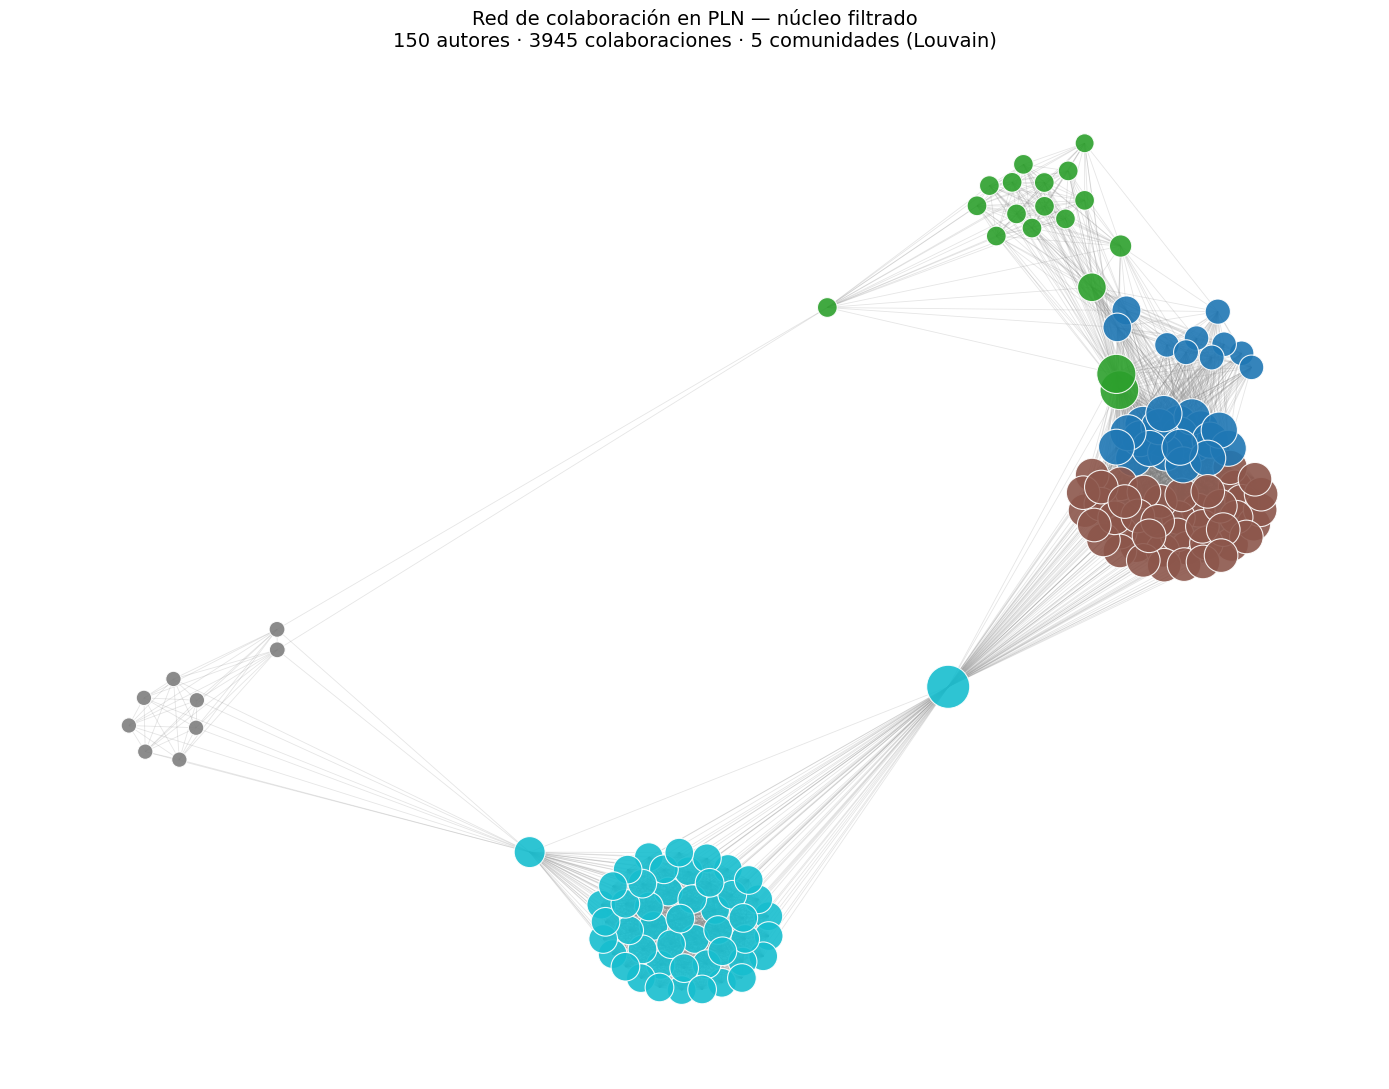

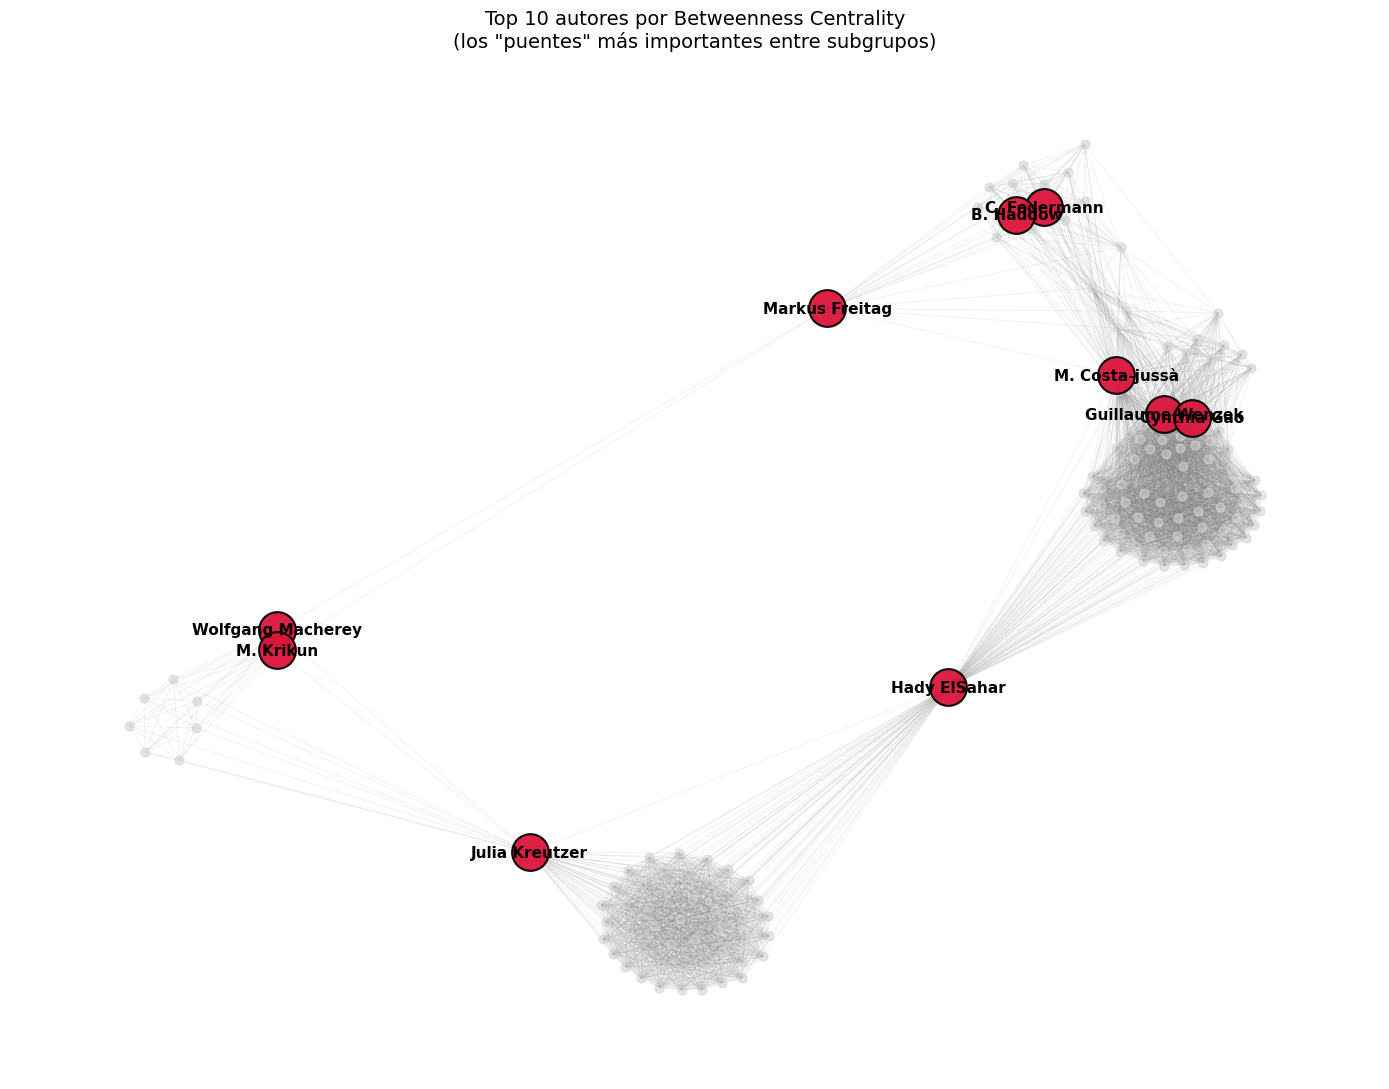

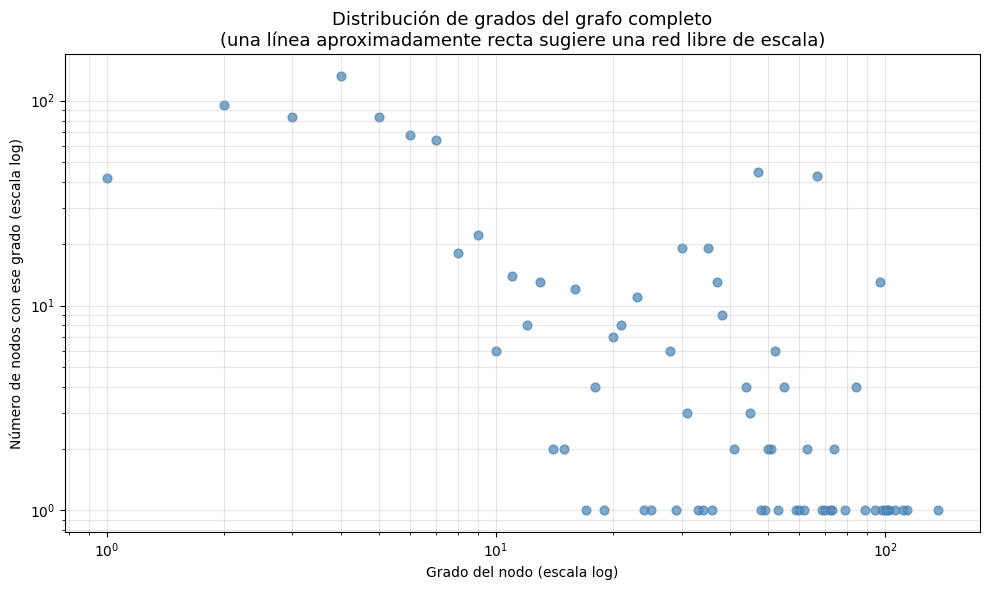

In [9]:
# Preparación
FIGS_DIR = Path('figs')
FIGS_DIR.mkdir(exist_ok=True)

# Layout compartido por las dos visualizaciones (mismas posiciones)
print('Calculando layout spring...')
node_positions = nx.spring_layout(giant, seed=42, k=0.3, iterations=80)

node_degrees = dict(giant.degree())
community_id_by_node = {n: giant.nodes[n]['community'] for n in giant.nodes()}


# Visualización 1: Grafo completo coloreado por comunidad
fig, ax = plt.subplots(figsize=(14, 11))

nx.draw_networkx_edges(
    giant, node_positions, ax=ax,
    alpha=0.2, width=0.6, edge_color='gray',
)
nx.draw_networkx_nodes(
    giant, node_positions, ax=ax,
    node_size=[50 + 8 * node_degrees[n] for n in giant.nodes()],
    node_color=[community_id_by_node[n] for n in giant.nodes()],
    cmap='tab10',
    alpha=0.9,
    linewidths=0.8,
    edgecolors='white',
)

ax.set_title(
    f'Red de colaboración en PLN — núcleo filtrado\n'
    f'{giant.number_of_nodes()} autores · {giant.number_of_edges()} colaboraciones · '
    f'{len(set(community_id_by_node.values()))} comunidades (Louvain)',
    fontsize=14,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'grafo_completo.png', dpi=150, bbox_inches='tight')
plt.show()


# Visualización 2: Destacando los top-10 por betweenness
top_betweenness = sorted(
    betweenness_centrality.items(), key=lambda item: item[1], reverse=True,
)[:10]
top_ids = {node_id for node_id, _ in top_betweenness}
non_top_ids = [n for n in giant.nodes() if n not in top_ids]

fig, ax = plt.subplots(figsize=(14, 11))

nx.draw_networkx_edges(
    giant, node_positions, ax=ax,
    alpha=0.15, width=0.5, edge_color='gray',
)
nx.draw_networkx_nodes(
    giant, node_positions, ax=ax,
    nodelist=non_top_ids,
    node_size=40,
    node_color='lightgray',
    alpha=0.6,
)
nx.draw_networkx_nodes(
    giant, node_positions, ax=ax,
    nodelist=list(top_ids),
    node_size=700,
    node_color='crimson',
    alpha=0.95,
    edgecolors='black',
    linewidths=1.5,
)
nx.draw_networkx_labels(
    giant, node_positions, ax=ax,
    labels={n: giant.nodes[n]['name'] for n in top_ids},
    font_size=11,
    font_weight='bold',
)

ax.set_title(
    'Top 10 autores por Betweenness Centrality\n'
    '(los "puentes" más importantes entre subgrupos)',
    fontsize=14,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'grafo_top_betweenness.png', dpi=150, bbox_inches='tight')
plt.show()


# Visualización 3 (bonus): Distribución de grados del grafo completo
# Usamos G_full para que el histograma muestre la cola larga real de la red.
all_degrees = [d for _, d in G_full.degree()]
degree_frequency = Counter(all_degrees)
degree_values = sorted(d for d in degree_frequency if d > 0)
frequencies = [degree_frequency[d] for d in degree_values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(degree_values, frequencies, alpha=0.7, s=40, color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Grado del nodo (escala log)')
ax.set_ylabel('Número de nodos con ese grado (escala log)')
ax.set_title(
    'Distribución de grados del grafo completo\n'
    '(una línea aproximadamente recta sugiere una red libre de escala)',
    fontsize=13,
)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'distribucion_grados.png', dpi=150, bbox_inches='tight')
plt.show()